# **Trabalho 2 - EEL891: Introdução ao Aprendizado de Máquina**

## **Regressão Multivariável - Estimar o preço de um imóvel a partir de suas características**

### Introdução
Este notebook contém a solução para o **Trabalho 2** da disciplina **EEL891 - Introdução ao Aprendizado de Máquina**, ofertada no período **2024-2**.  
O objetivo deste trabalho é desenvolver um modelo de regressão multivariável para estimar o preço de venda de imóveis residenciais com base em diversas características descritas no conjunto de dados.

O preço de venda de imóveis pode variar amplamente com base em diversos fatores, como localização, tipo de imóvel, e características específicas, como a presença de elementos diferenciadores. Este projeto visa **desenvolver uma estimativa precisa** de preços de imóveis para apoiar os interessados na compra ou venda de propriedades.

---

### Objetivo do Projeto
O objetivo é construir um modelo preditivo capaz de estimar o **preço de venda** de um imóvel, com base nas suas características, como tipo, localização, número de quartos, vagas de garagem, área útil, e outros elementos diferenciadores.

### Descrição dos Dados
Você terá acesso a um **conjunto de dados** contendo informações sobre 6.683 imóveis residenciais, coletados de ofertas de venda publicadas em um site especializado. O conjunto inclui 4.683 amostras para treinamento e 2.000 amostras para teste.

- **Número de amostras históricas (treinamento)**: 4.683  
- **Número de amostras de teste**: 2.000  
- **Alvo**: `preco`, representando o preço de venda do imóvel.  

---

### Etapas do Projeto
- **Exploração e pré-processamento dos dados**:
  - Análise exploratória (EDA)
  - Tratamento de valores faltantes e outliers  
  - Codificação de variáveis categóricas (ex: tipo de imóvel, bairro, tipo de vendedor)
  - Normalização/Padronização dos dados
  
- **Desenvolvimento do Modelo**:
  - Escolha de algoritmos de regressão (ex: regressão linear, árvore de decisão, random forest)
  - Ajuste de hiperparâmetros

- **Avaliação do Modelo**:
  - Divisão dos dados em treino/validação  
  - Avaliação com métricas apropriadas (erro absoluto médio, R², etc.)
  
- **Submissão no Kaggle**:
  - Preparação do arquivo de submissão com as estimativas de preço  
  - Comparação dos resultados com os colegas na plataforma Kaggle

---

### Ferramentas e Bibliotecas
- **Python 3.x**  
- **Bibliotecas**:  
  - `pandas` - Manipulação de dados  
  - `numpy` - Operações matemáticas  
  - `scikit-learn` - Modelos de aprendizado de máquina  
  - `matplotlib` e `seaborn` - Visualização de dados  

---

### Informações do Aluno
- **Nome**: Leonardo Soares da Costa Tanaka  
- **Curso**: Engenharia de Controle e Automação  
- **Faculdade**: Universidade Federal do Rio de Janeiro (UFRJ)

---

### Início do Desenvolvimento
Vamos começar o desenvolvimento carregando as bibliotecas necessárias e explorando o conjunto de dados para realizar o pré-processamento e análise exploratória.


## 1. Importação das bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Coleta de Dados

In [3]:
df_train = pd.read_csv("data/conjunto_de_treinamento.csv")
df_test = pd.read_csv("data/conjunto_de_teste.csv")
print(list(df_train.columns))

['Id', 'tipo', 'bairro', 'tipo_vendedor', 'quartos', 'suites', 'vagas', 'area_util', 'area_extra', 'diferenciais', 'churrasqueira', 'estacionamento', 'piscina', 'playground', 'quadra', 's_festas', 's_jogos', 's_ginastica', 'sauna', 'vista_mar', 'preco']


In [4]:
df_train.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,...,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,Casa,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,...,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,Apartamento,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,680000.0
2,2002,Apartamento,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,...,0,0,0,0,0,0,0,0,0,450000.0
3,2003,Apartamento,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,Apartamento,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,350000.0


In [5]:
df_test.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar
0,0,Apartamento,Pina,Imobiliaria,4,4,3,182,0,copa e playground,0,0,0,1,0,0,0,0,0,0
1,1,Apartamento,Tamarineira,Imobiliaria,2,0,1,85,0,nenhum,0,0,0,0,0,0,0,0,0,0
2,2,Apartamento,Boa Viagem,Imobiliaria,3,1,2,115,20,piscina e churrasqueira,1,0,1,0,0,0,0,0,0,0
3,3,Apartamento,Iputinga,Imobiliaria,3,0,1,92,0,nenhum,0,0,0,0,0,0,0,0,0,0
4,4,Apartamento,Engenho do Meio,Imobiliaria,3,1,1,65,0,piscina e copa,0,0,1,0,0,0,0,0,0,0


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4683 entries, 0 to 4682
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              4683 non-null   int64  
 1   tipo            4683 non-null   object 
 2   bairro          4683 non-null   object 
 3   tipo_vendedor   4683 non-null   object 
 4   quartos         4683 non-null   int64  
 5   suites          4683 non-null   int64  
 6   vagas           4683 non-null   int64  
 7   area_util       4683 non-null   int64  
 8   area_extra      4683 non-null   int64  
 9   diferenciais    4683 non-null   object 
 10  churrasqueira   4683 non-null   int64  
 11  estacionamento  4683 non-null   int64  
 12  piscina         4683 non-null   int64  
 13  playground      4683 non-null   int64  
 14  quadra          4683 non-null   int64  
 15  s_festas        4683 non-null   int64  
 16  s_jogos         4683 non-null   int64  
 17  s_ginastica     4683 non-null   i

In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Id              2000 non-null   int64 
 1   tipo            2000 non-null   object
 2   bairro          2000 non-null   object
 3   tipo_vendedor   2000 non-null   object
 4   quartos         2000 non-null   int64 
 5   suites          2000 non-null   int64 
 6   vagas           2000 non-null   int64 
 7   area_util       2000 non-null   int64 
 8   area_extra      2000 non-null   int64 
 9   diferenciais    2000 non-null   object
 10  churrasqueira   2000 non-null   int64 
 11  estacionamento  2000 non-null   int64 
 12  piscina         2000 non-null   int64 
 13  playground      2000 non-null   int64 
 14  quadra          2000 non-null   int64 
 15  s_festas        2000 non-null   int64 
 16  s_jogos         2000 non-null   int64 
 17  s_ginastica     2000 non-null   int64 
 18  sauna   

## 3. Tratamento dos Dados

In [8]:
# Combina os dois DataFrames
df = pd.concat([df_train, df_test], ignore_index=True)
df.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,...,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,Casa,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,...,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,Apartamento,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,680000.0
2,2002,Apartamento,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,...,0,0,0,0,0,0,0,0,0,450000.0
3,2003,Apartamento,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,Apartamento,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,350000.0


In [9]:
# Aplicando One-Hot Encoding do Tipo
df = pd.get_dummies(df, columns=['tipo'], prefix='tipo',dtype=int)
df.head()

,Id,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,...,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco,tipo_Apartamento,tipo_Casa,tipo_Loft,tipo_Quitinete
0,2000,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,0,...,0,0,0,0,0,1000000.0,0,1,0,0
1,2001,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,1,...,0,0,0,0,0,680000.0,1,0,0,0
2,2002,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,0,...,0,0,0,0,0,450000.0,1,0,0,0
3,2003,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,1,...,0,0,0,0,0,1080000.0,1,0,0,0
4,2004,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,1,...,0,0,0,0,0,350000.0,1,0,0,0


In [10]:
# Aplicando One-Hot Encoding do Bairro
df = pd.get_dummies(df, columns=['bairro'], prefix='bairro',dtype=int)
df.head()

,Id,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,...,bairro_Setubal,bairro_Soledade,bairro_Sto Amaro,bairro_Sto Antonio,bairro_Tamarineira,bairro_Tejipio,bairro_Torre,bairro_Torreao,bairro_Varzea,bairro_Zumbi
0,2000,Imobiliaria,3,3,5,223,167,piscina e copa,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2001,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2002,Imobiliaria,3,1,0,53,0,nenhum,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2003,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2004,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# Substitui 'Imobiliaria' por 1 e 'Pessoa Fisica' por 0 na coluna 'tipo_vendedor'
df['tipo_vendedor'] = df['tipo_vendedor'].map({'Imobiliaria': 1, 'Pessoa Fisica': 0})
print(df['tipo_vendedor'].dtype)
df.head()

int64


,Id,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,...,bairro_Setubal,bairro_Soledade,bairro_Sto Amaro,bairro_Sto Antonio,bairro_Tamarineira,bairro_Tejipio,bairro_Torre,bairro_Torreao,bairro_Varzea,bairro_Zumbi
0,2000,1,3,3,5,223,167,piscina e copa,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2001,1,4,4,2,157,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2002,1,3,1,0,53,0,nenhum,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2003,1,4,3,2,149,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2004,1,2,1,1,54,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df.drop(columns=['diferenciais'], inplace=True)
df.head()

,Id,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,churrasqueira,estacionamento,piscina,...,bairro_Setubal,bairro_Soledade,bairro_Sto Amaro,bairro_Sto Antonio,bairro_Tamarineira,bairro_Tejipio,bairro_Torre,bairro_Torreao,bairro_Varzea,bairro_Zumbi
0,2000,1,3,3,5,223,167,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2001,1,4,4,2,157,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2002,1,3,1,0,53,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2003,1,4,3,2,149,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,2004,1,2,1,1,54,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


## 4. Análise dos Dados

In [13]:
df.columns

Index(['Id', 'tipo_vendedor', 'quartos', 'suites', 'vagas', 'area_util',
       'area_extra', 'churrasqueira', 'estacionamento', 'piscina',
       'playground', 'quadra', 's_festas', 's_jogos', 's_ginastica', 'sauna',
       'vista_mar', 'preco', 'tipo_Apartamento', 'tipo_Casa', 'tipo_Loft',
       'tipo_Quitinete', 'bairro_Aflitos', 'bairro_Afogados',
       'bairro_Agua Fria', 'bairro_Apipucos', 'bairro_Areias', 'bairro_Arruda',
       'bairro_Barro', 'bairro_Beberibe', 'bairro_Beira Rio', 'bairro_Benfica',
       'bairro_Boa Viagem', 'bairro_Boa Vista', 'bairro_Bongi',
       'bairro_Cajueiro', 'bairro_Campo Grande', 'bairro_Casa Amarela',
       'bairro_Casa Forte', 'bairro_Caxanga', 'bairro_Centro',
       'bairro_Cid Universitaria', 'bairro_Coelhos', 'bairro_Cohab',
       'bairro_Cordeiro', 'bairro_Derby', 'bairro_Dois Irmaos',
       'bairro_Encruzilhada', 'bairro_Engenho do Meio', 'bairro_Espinheiro',
       'bairro_Estancia', 'bairro_Fundao', 'bairro_Gracas', 'bairro_Guabirab

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\411863462.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tipo_vendedor', y='preco', data=df, palette='pastel', showfliers=False)


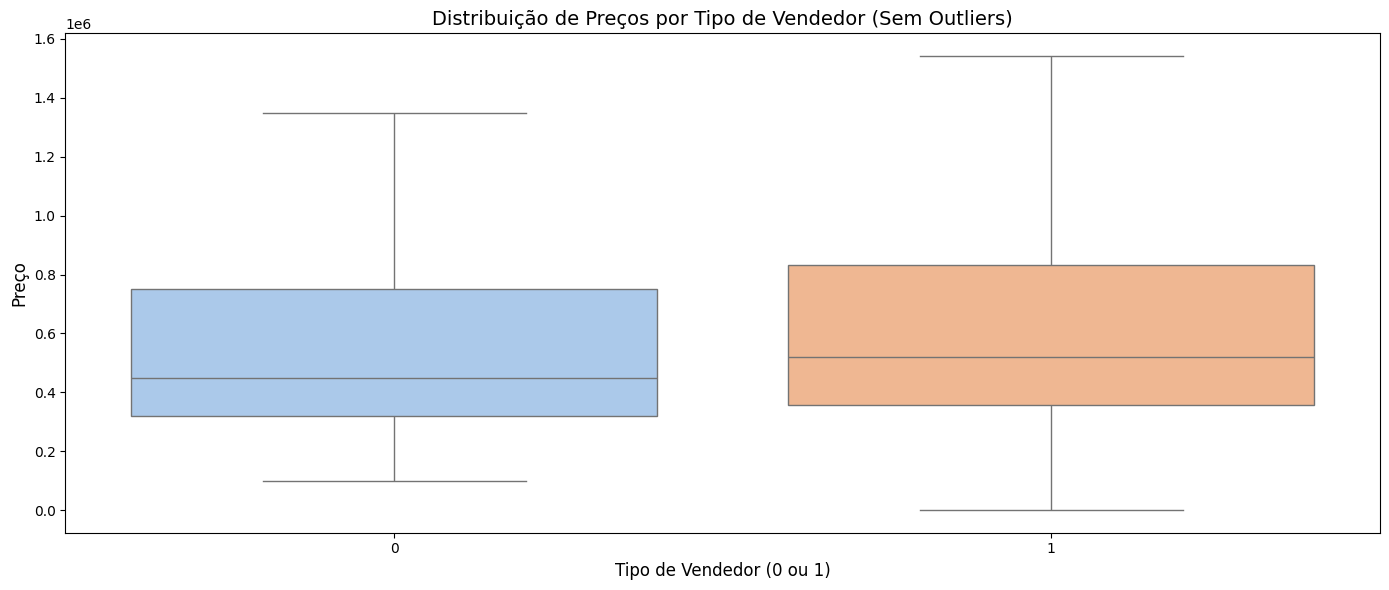

In [ ]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers
sns.boxplot(x='tipo_vendedor', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Tipo de Vendedor (Sem Outliers)', fontsize=14)
plt.xlabel('Tipo de Vendedor (0 ou 1)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\4088204510.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quartos', y='preco', data=df, palette='viridis', showfliers=False)


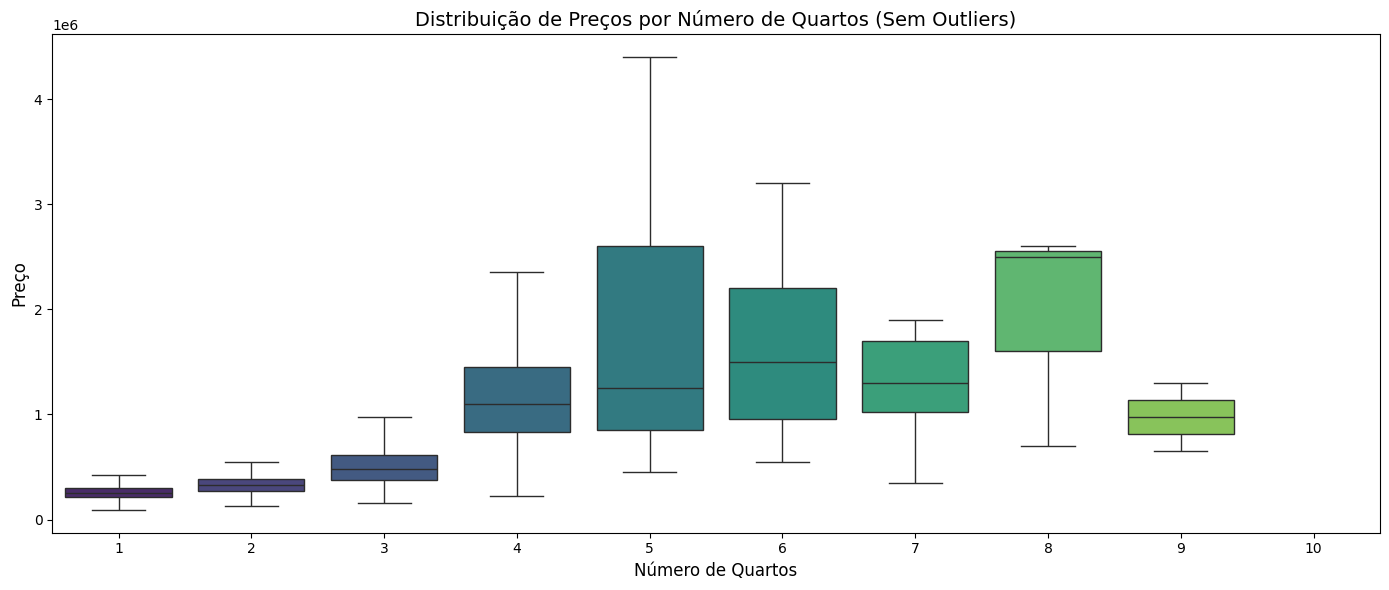

In [15]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot para coluna 'quartos'
sns.boxplot(x='quartos', y='preco', data=df, palette='viridis', showfliers=False)
plt.title('Distribuição de Preços por Número de Quartos (Sem Outliers)', fontsize=14)
plt.xlabel('Número de Quartos', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\2273042639.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='suites', y='preco', data=df, palette='coolwarm', showfliers=False)


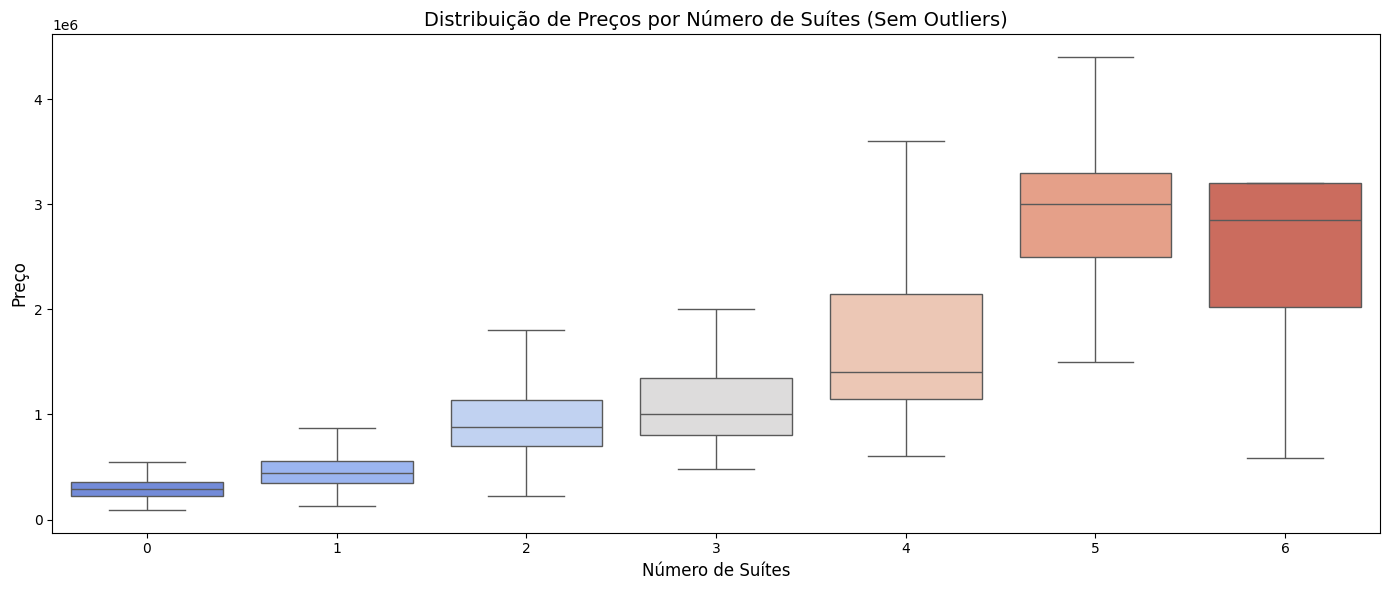

In [16]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot para coluna 'suites'
sns.boxplot(x='suites', y='preco', data=df, palette='coolwarm', showfliers=False)
plt.title('Distribuição de Preços por Número de Suítes (Sem Outliers)', fontsize=14)
plt.xlabel('Número de Suítes', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\1861699145.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='vagas', y='preco', data=df, palette='crest', showfliers=False)


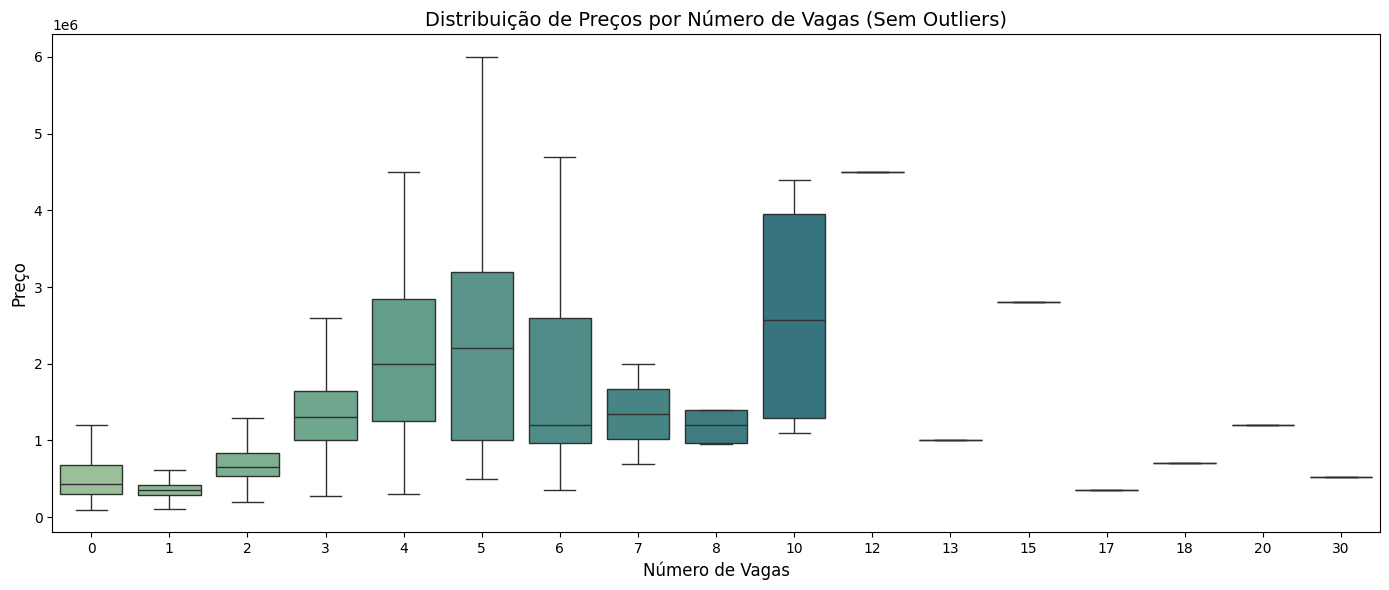

In [17]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot para coluna 'vagas'
sns.boxplot(x='vagas', y='preco', data=df, palette='crest', showfliers=False)
plt.title('Distribuição de Preços por Número de Vagas (Sem Outliers)', fontsize=14)
plt.xlabel('Número de Vagas', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

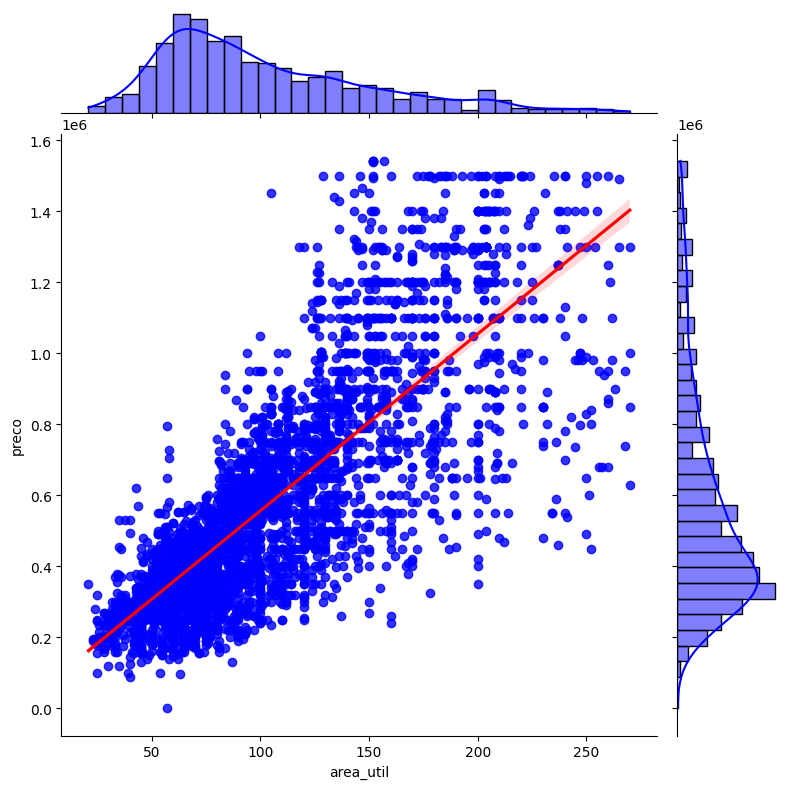

In [18]:
# Remover outliers com base no IQR (Interquartile Range) para 'area_util' e 'preco'
Q1_area_util = df['area_util'].quantile(0.25)
Q3_area_util = df['area_util'].quantile(0.75)
IQR_area_util = Q3_area_util - Q1_area_util
lower_bound_area_util = Q1_area_util - 1.5 * IQR_area_util
upper_bound_area_util = Q3_area_util + 1.5 * IQR_area_util

Q1_preco = df['preco'].quantile(0.25)
Q3_preco = df['preco'].quantile(0.75)
IQR_preco = Q3_preco - Q1_preco
lower_bound_preco = Q1_preco - 1.5 * IQR_preco
upper_bound_preco = Q3_preco + 1.5 * IQR_preco

# Filtrar os dados para remover os outliers
df_filtered = df[(df['area_util'] >= lower_bound_area_util) & (df['area_util'] <= upper_bound_area_util) &
                 (df['preco'] >= lower_bound_preco) & (df['preco'] <= upper_bound_preco)]

# Configurando o tamanho da figura
plt.figure(figsize=(10, 8))

# Criando o jointplot entre area_util e preco com regressão
g = sns.jointplot(data=df_filtered, x='area_util', y='preco', kind='reg', 
                  height=8, joint_kws={'color': 'blue'}, line_kws={'color': 'red'}, 
                  marginal_kws={'color': 'blue'})

# Exibindo o gráfico
plt.show()

<Figure size 1000x800 with 0 Axes>

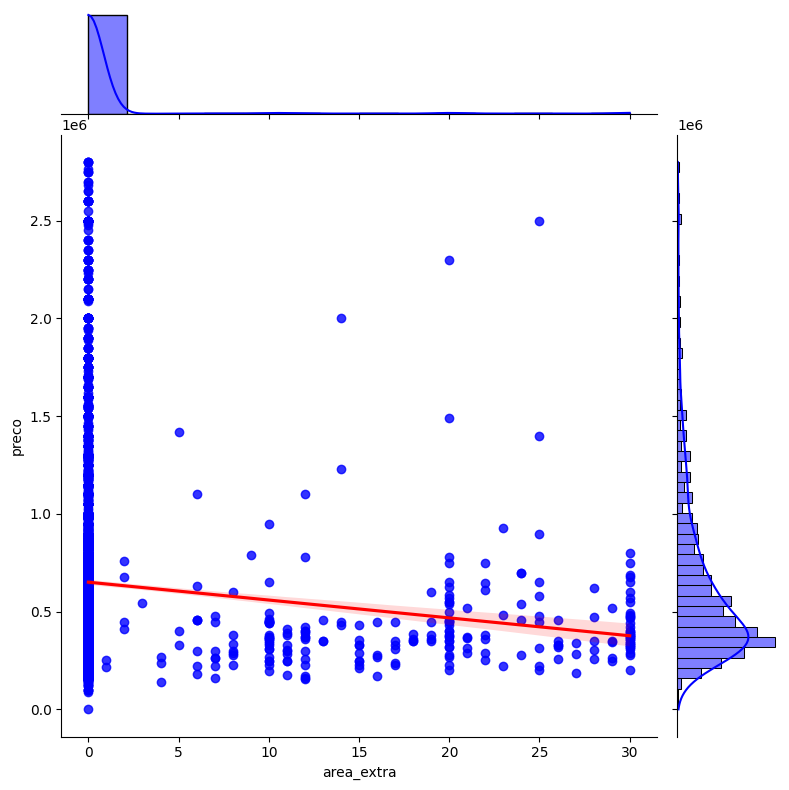

In [23]:
# Configurando o tamanho da figura
plt.figure(figsize=(10, 8))

# Criando o jointplot entre area_extra e preco com regressão
g = sns.jointplot(data=df_filtered, x='area_extra', y='preco', kind='reg', 
                  height=8, joint_kws={'color': 'blue'}, line_kws={'color': 'red'}, 
                  marginal_kws={'color': 'blue'})

# Exibindo o gráfico
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\1362955900.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churrasqueira', y='preco', data=df, palette='pastel', showfliers=False)


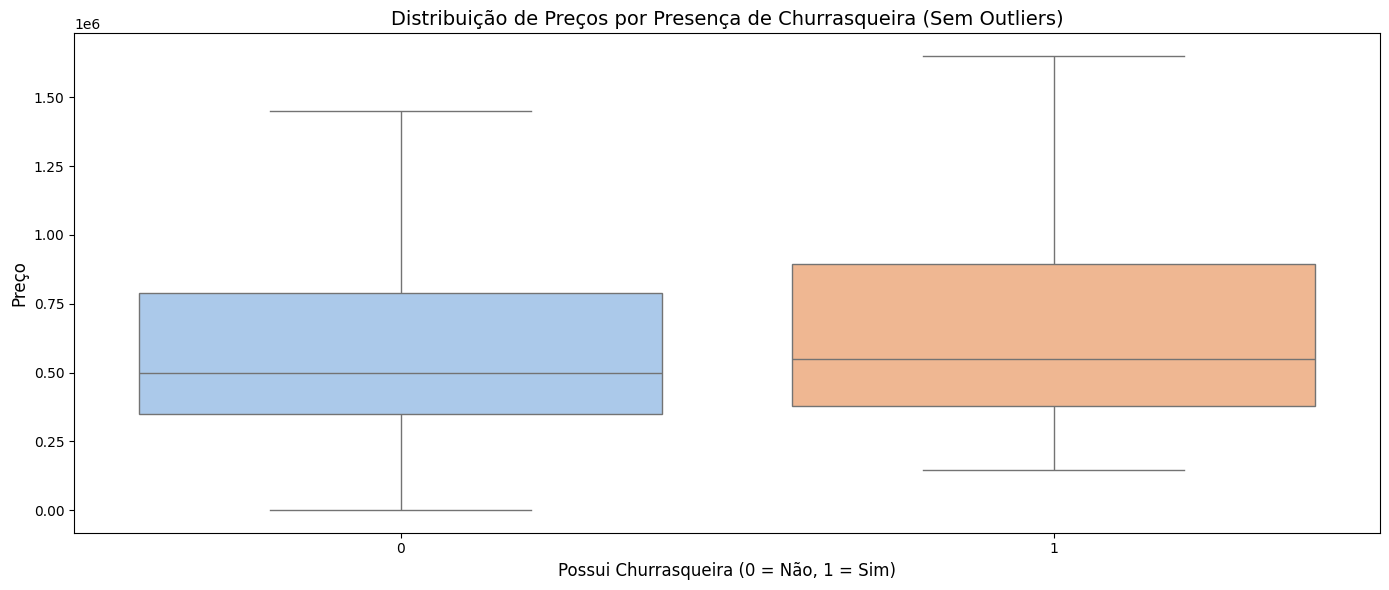

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 'churrasqueira'
sns.boxplot(x='churrasqueira', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Presença de Churrasqueira (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Churrasqueira (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\773949063.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='estacionamento', y='preco', data=df, palette='pastel', showfliers=False)


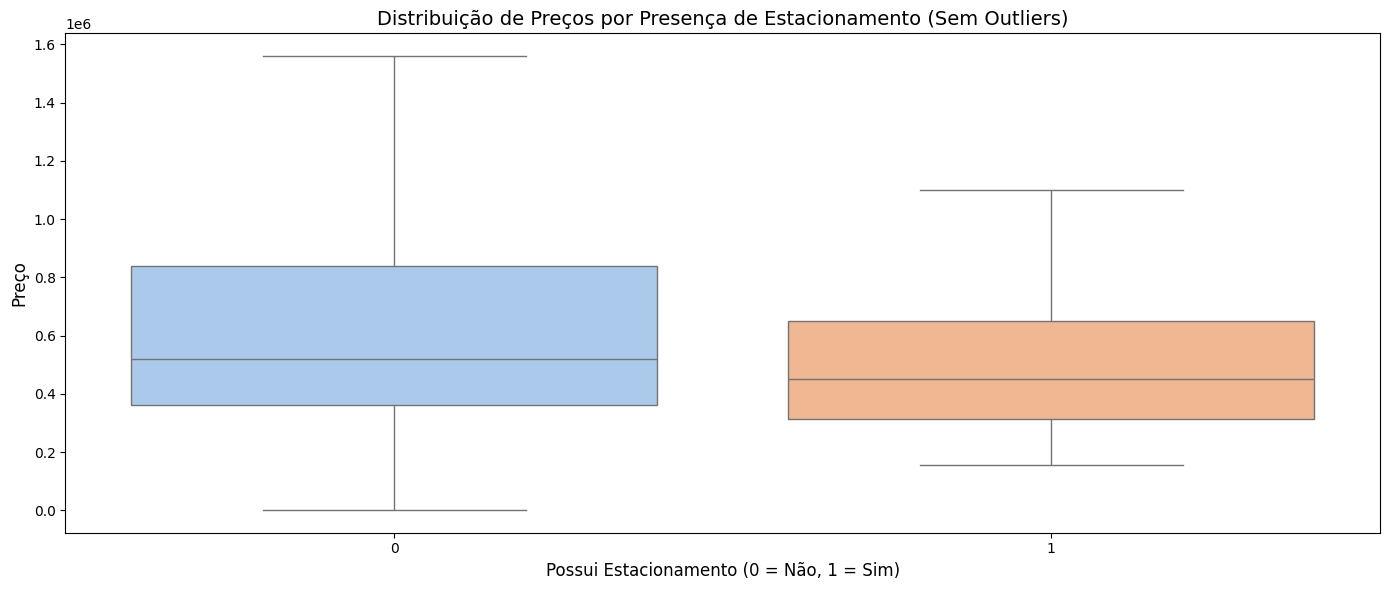

In [25]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 'estacionamento'
sns.boxplot(x='estacionamento', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Presença de Estacionamento (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Estacionamento (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\3319908061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='piscina', y='preco', data=df, palette='pastel', showfliers=False)


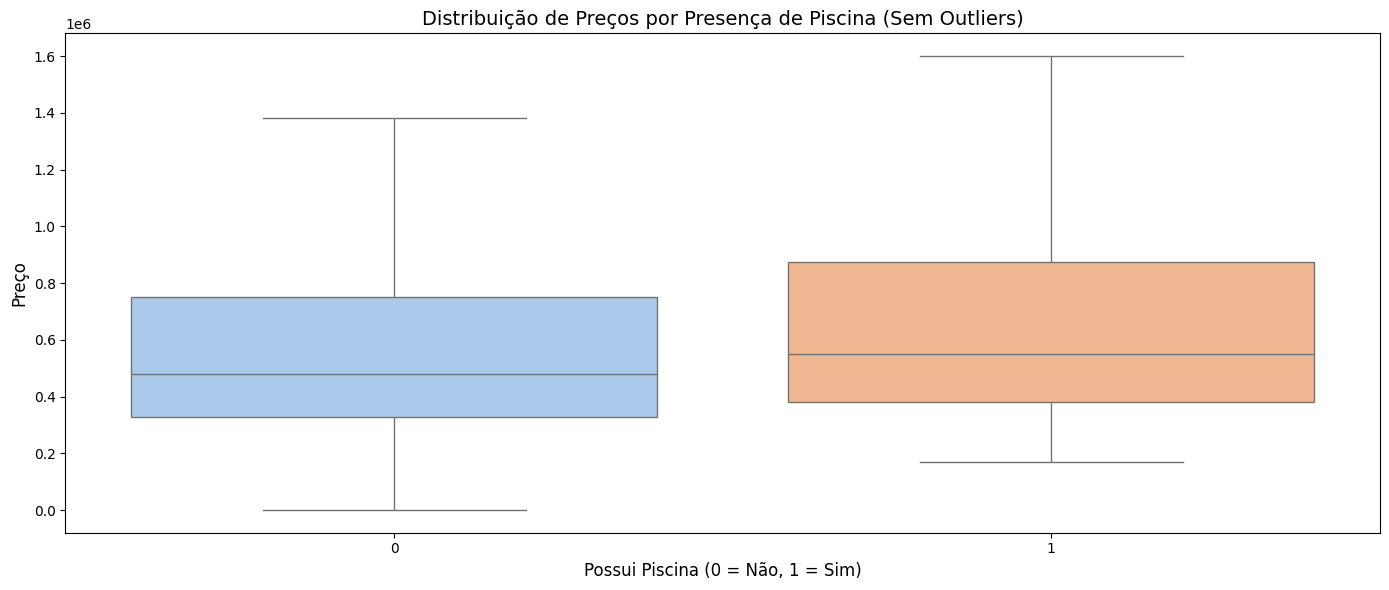

In [26]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 'piscina'
sns.boxplot(x='piscina', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Presença de Piscina (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Piscina (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\3184627789.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='playground', y='preco', data=df, palette='pastel', showfliers=False)


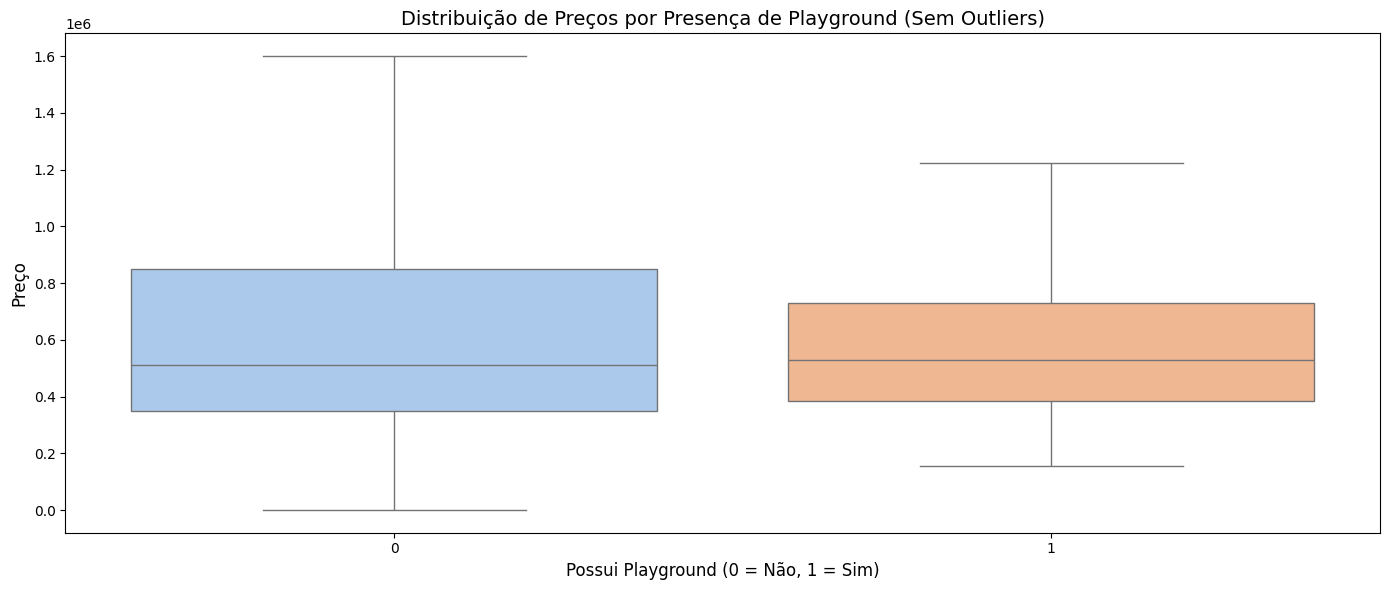

In [27]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 'playground'
sns.boxplot(x='playground', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Presença de Playground (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Playground (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\654165299.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quadra', y='preco', data=df, palette='pastel', showfliers=False)


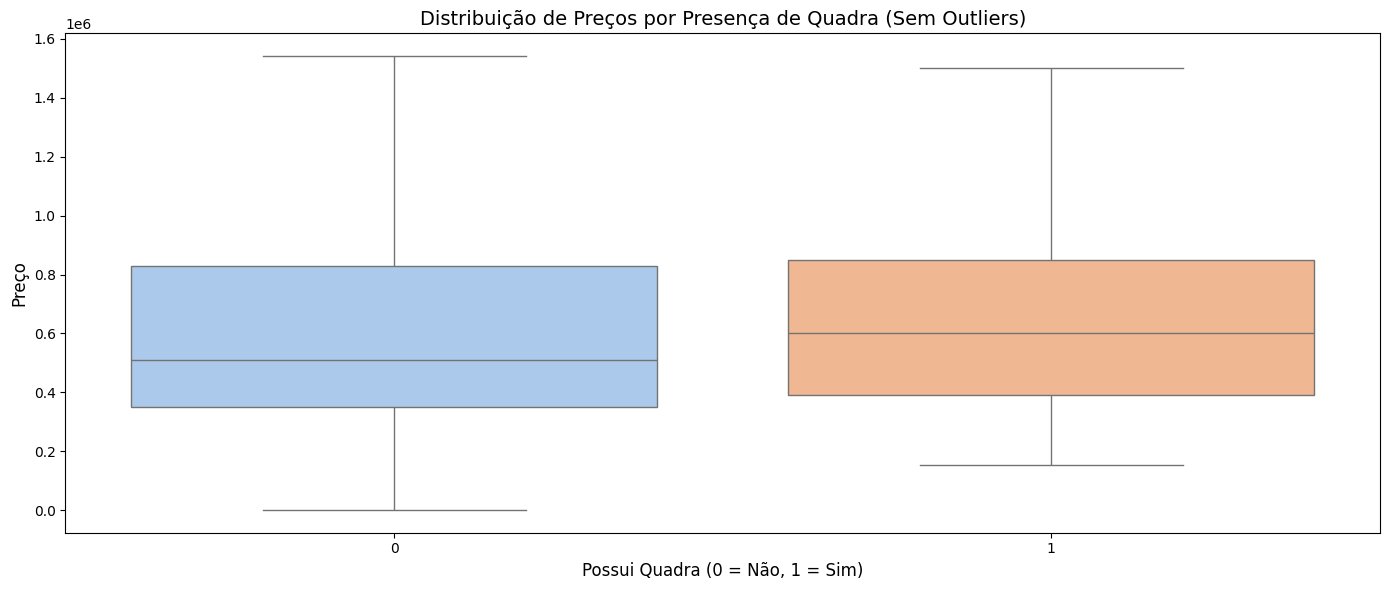

In [28]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 'quadra'
sns.boxplot(x='quadra', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Presença de Quadra (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Quadra (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\2564113177.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='s_festas', y='preco', data=df, palette='pastel', showfliers=False)


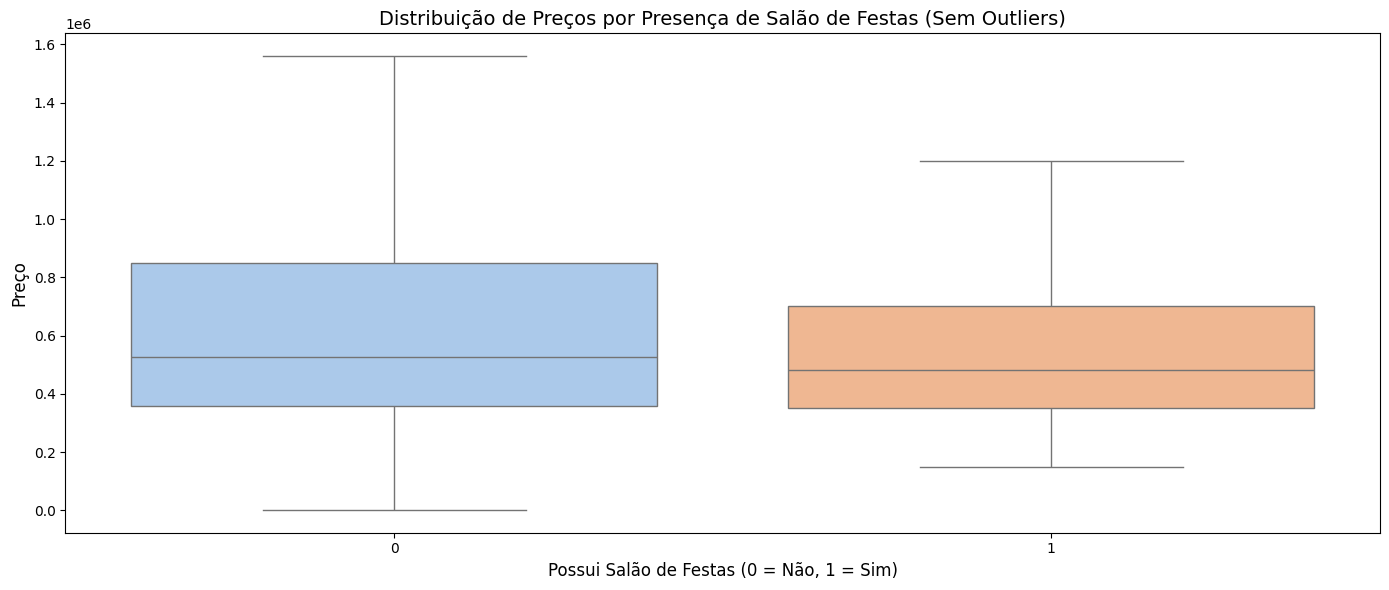

In [29]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 's_festas'
sns.boxplot(x='s_festas', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Presença de Salão de Festas (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Salão de Festas (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\3031090527.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='s_jogos', y='preco', data=df, palette='pastel', showfliers=False)


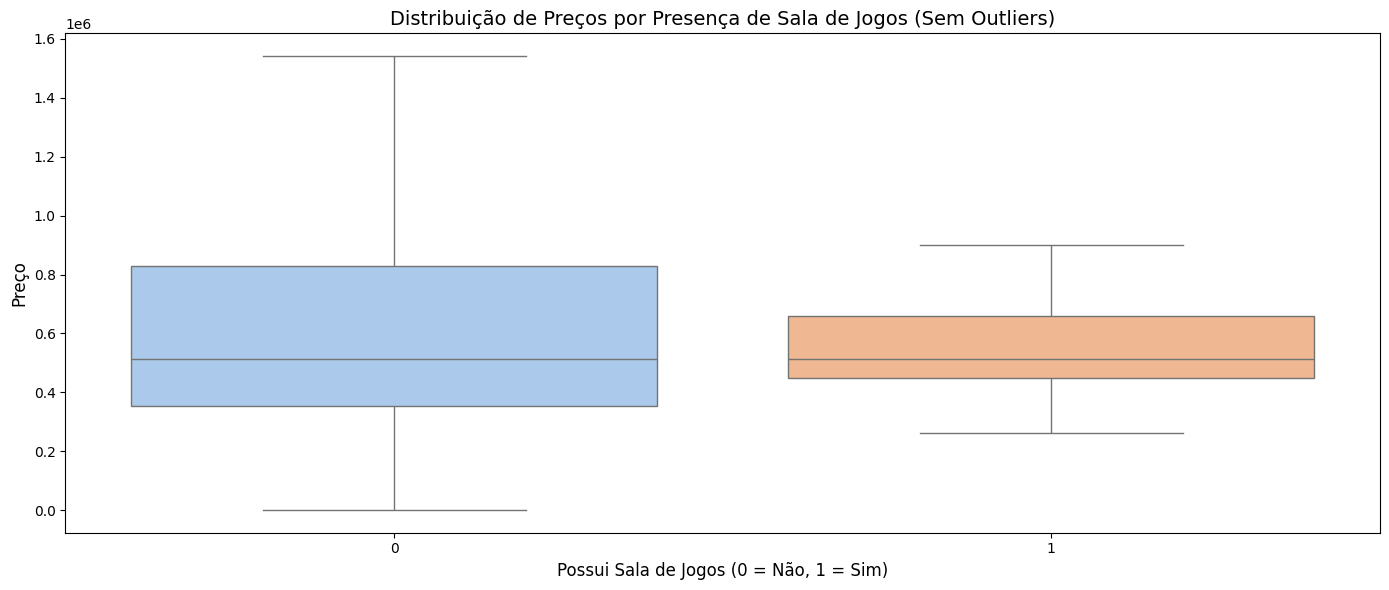

In [30]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 's_jogos'
sns.boxplot(x='s_jogos', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Presença de Sala de Jogos (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Sala de Jogos (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\1266240711.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='s_ginastica', y='preco', data=df, palette='pastel', showfliers=False)


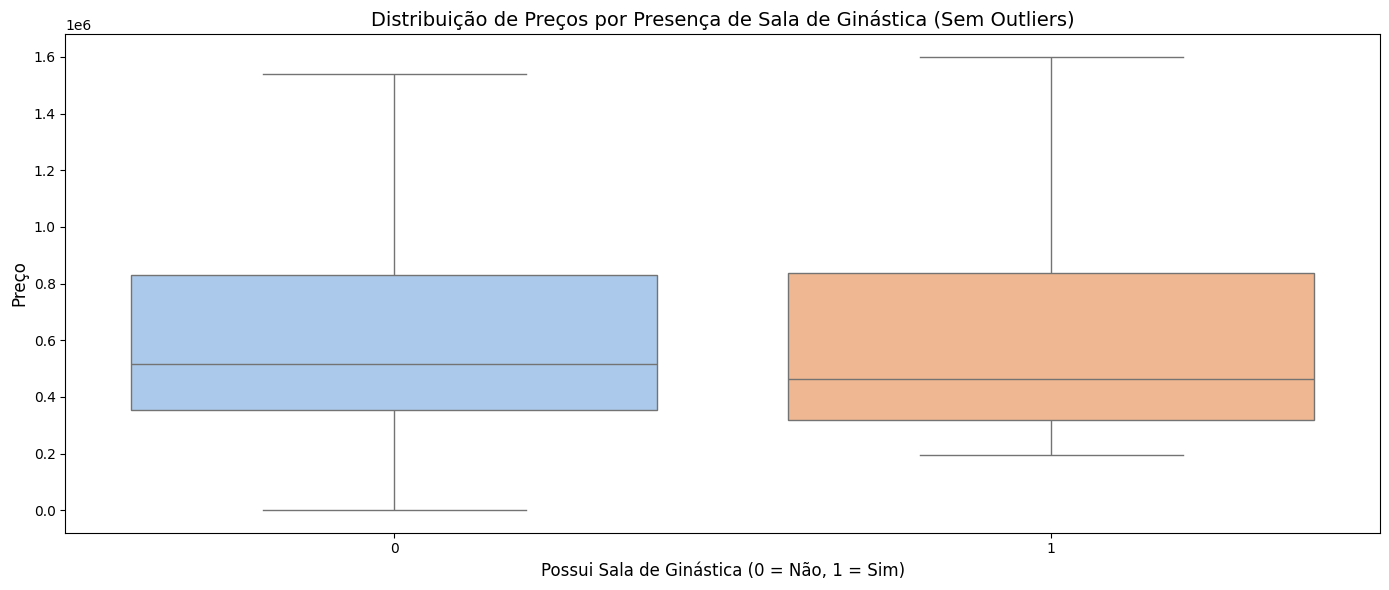

In [31]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 's_ginastica'
sns.boxplot(x='s_ginastica', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Presença de Sala de Ginástica (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Sala de Ginástica (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\592172861.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sauna', y='preco', data=df, palette='pastel', showfliers=False)


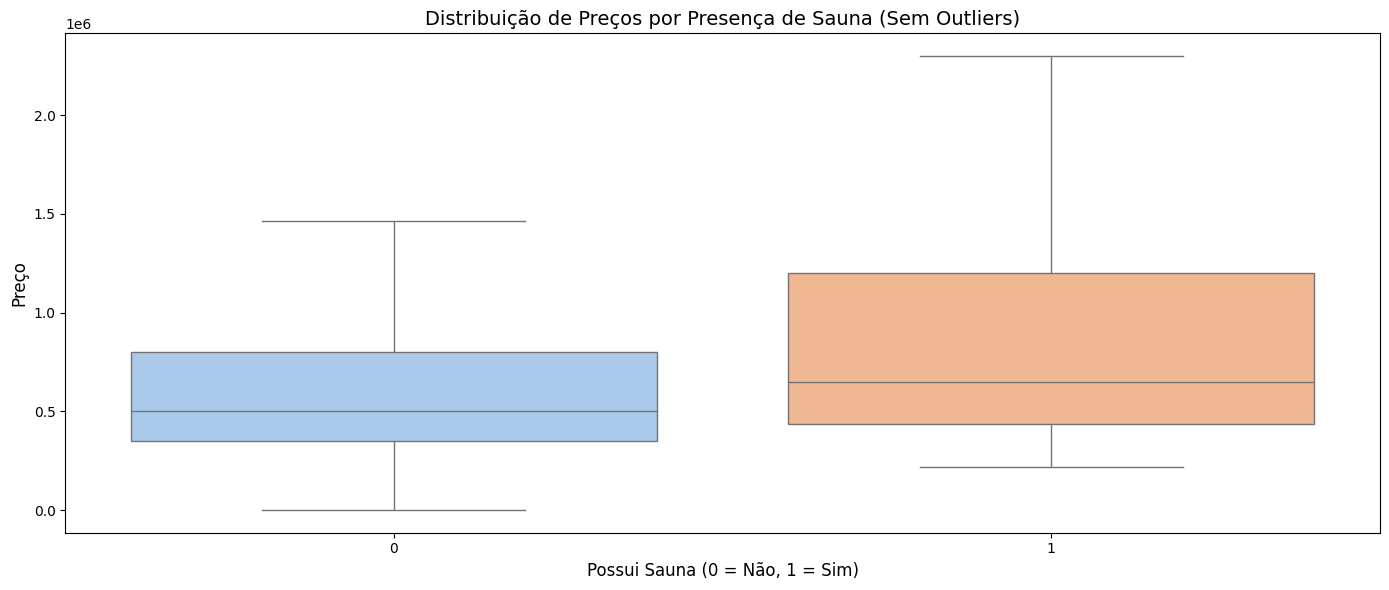

In [32]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 'sauna'
sns.boxplot(x='sauna', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Presença de Sauna (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Sauna (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\2136453516.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='vista_mar', y='preco', data=df, palette='pastel', showfliers=False)


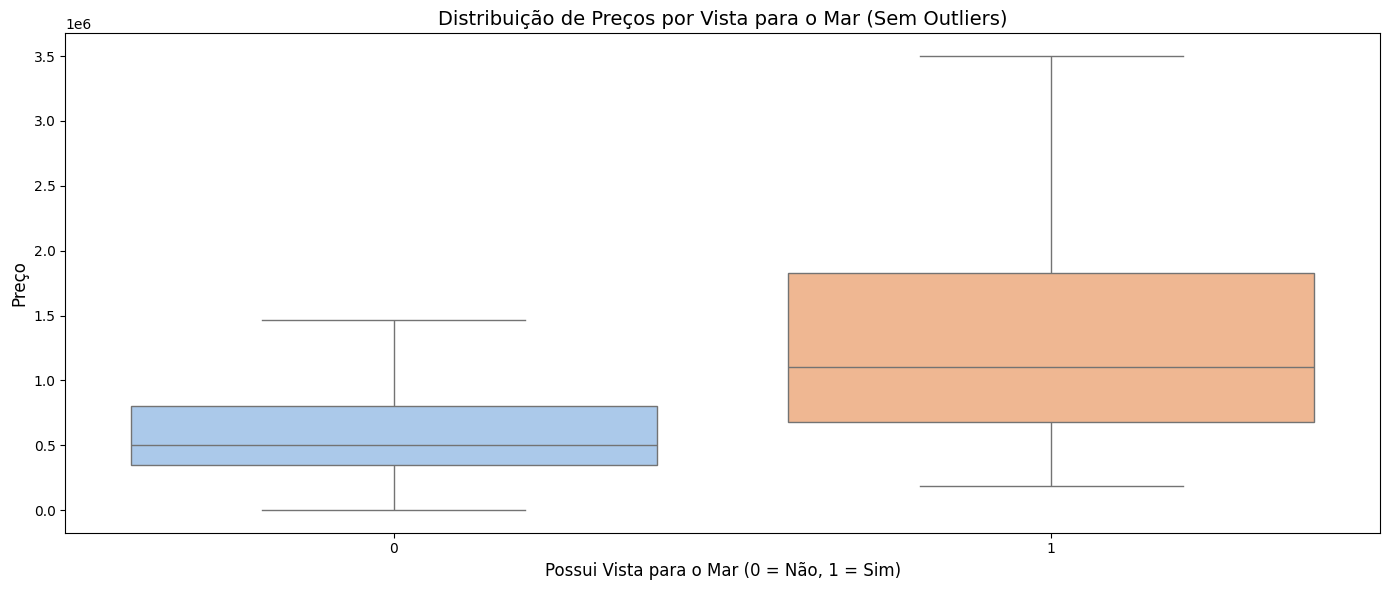

In [33]:
# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot sem outliers para a coluna binária 'vista_mar'
sns.boxplot(x='vista_mar', y='preco', data=df, palette='pastel', showfliers=False)
plt.title('Distribuição de Preços por Vista para o Mar (Sem Outliers)', fontsize=14)
plt.xlabel('Possui Vista para o Mar (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Mostrar gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\302721341.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tipo_imovel', y='preco', data=df_melted, palette='pastel', showfliers=False)


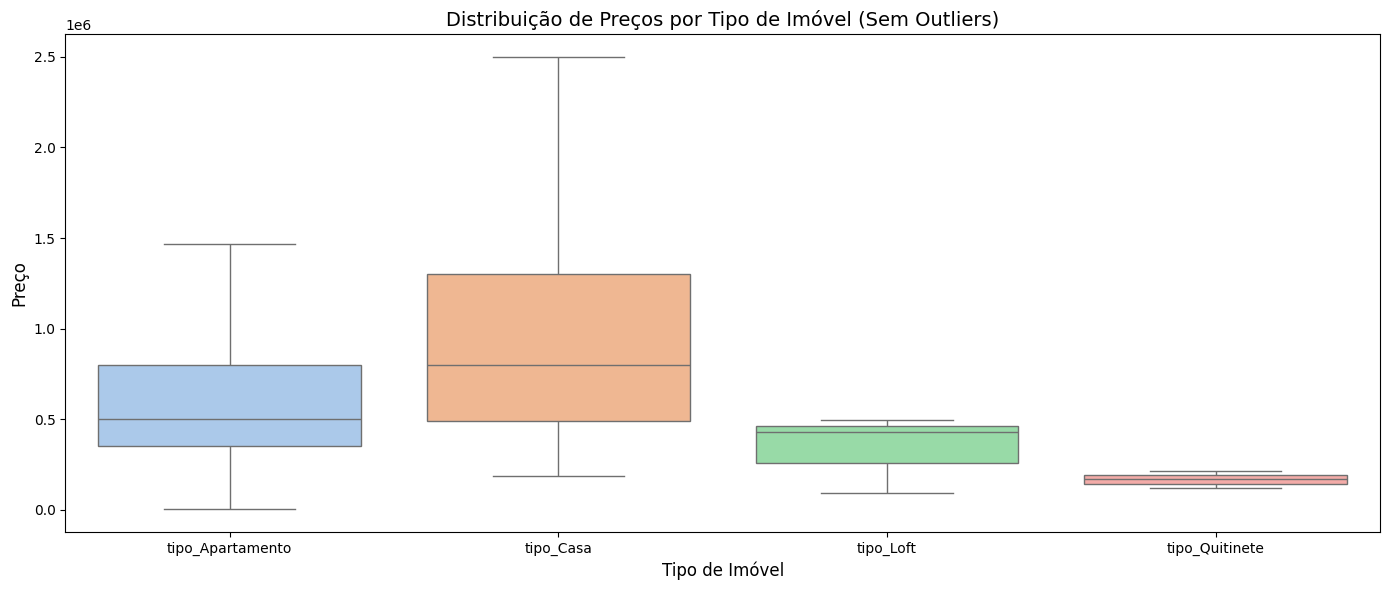

In [34]:
# Transformar as colunas binárias em uma única coluna 'tipo_imovel'
df_melted = df.melt(id_vars=['preco'], value_vars=['tipo_Apartamento', 'tipo_Casa', 'tipo_Loft', 'tipo_Quitinete'],
                    var_name='tipo_imovel', value_name='presente')

# Filtrando apenas os casos onde o valor de 'presente' é 1
df_melted = df_melted[df_melted['presente'] == 1]

# Configurar tamanho da figura
plt.figure(figsize=(14, 6))

# Boxplot para os tipos de imóvel
sns.boxplot(x='tipo_imovel', y='preco', data=df_melted, palette='pastel', showfliers=False)

# Títulos e rótulos
plt.title('Distribuição de Preços por Tipo de Imóvel (Sem Outliers)', fontsize=14)
plt.xlabel('Tipo de Imóvel', fontsize=12)
plt.ylabel('Preço', fontsize=12)

# Melhor organização do gráfico
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23560\2394474506.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bairro', y='preco', data=df_melted_bairros, palette='pastel', showfliers=False)


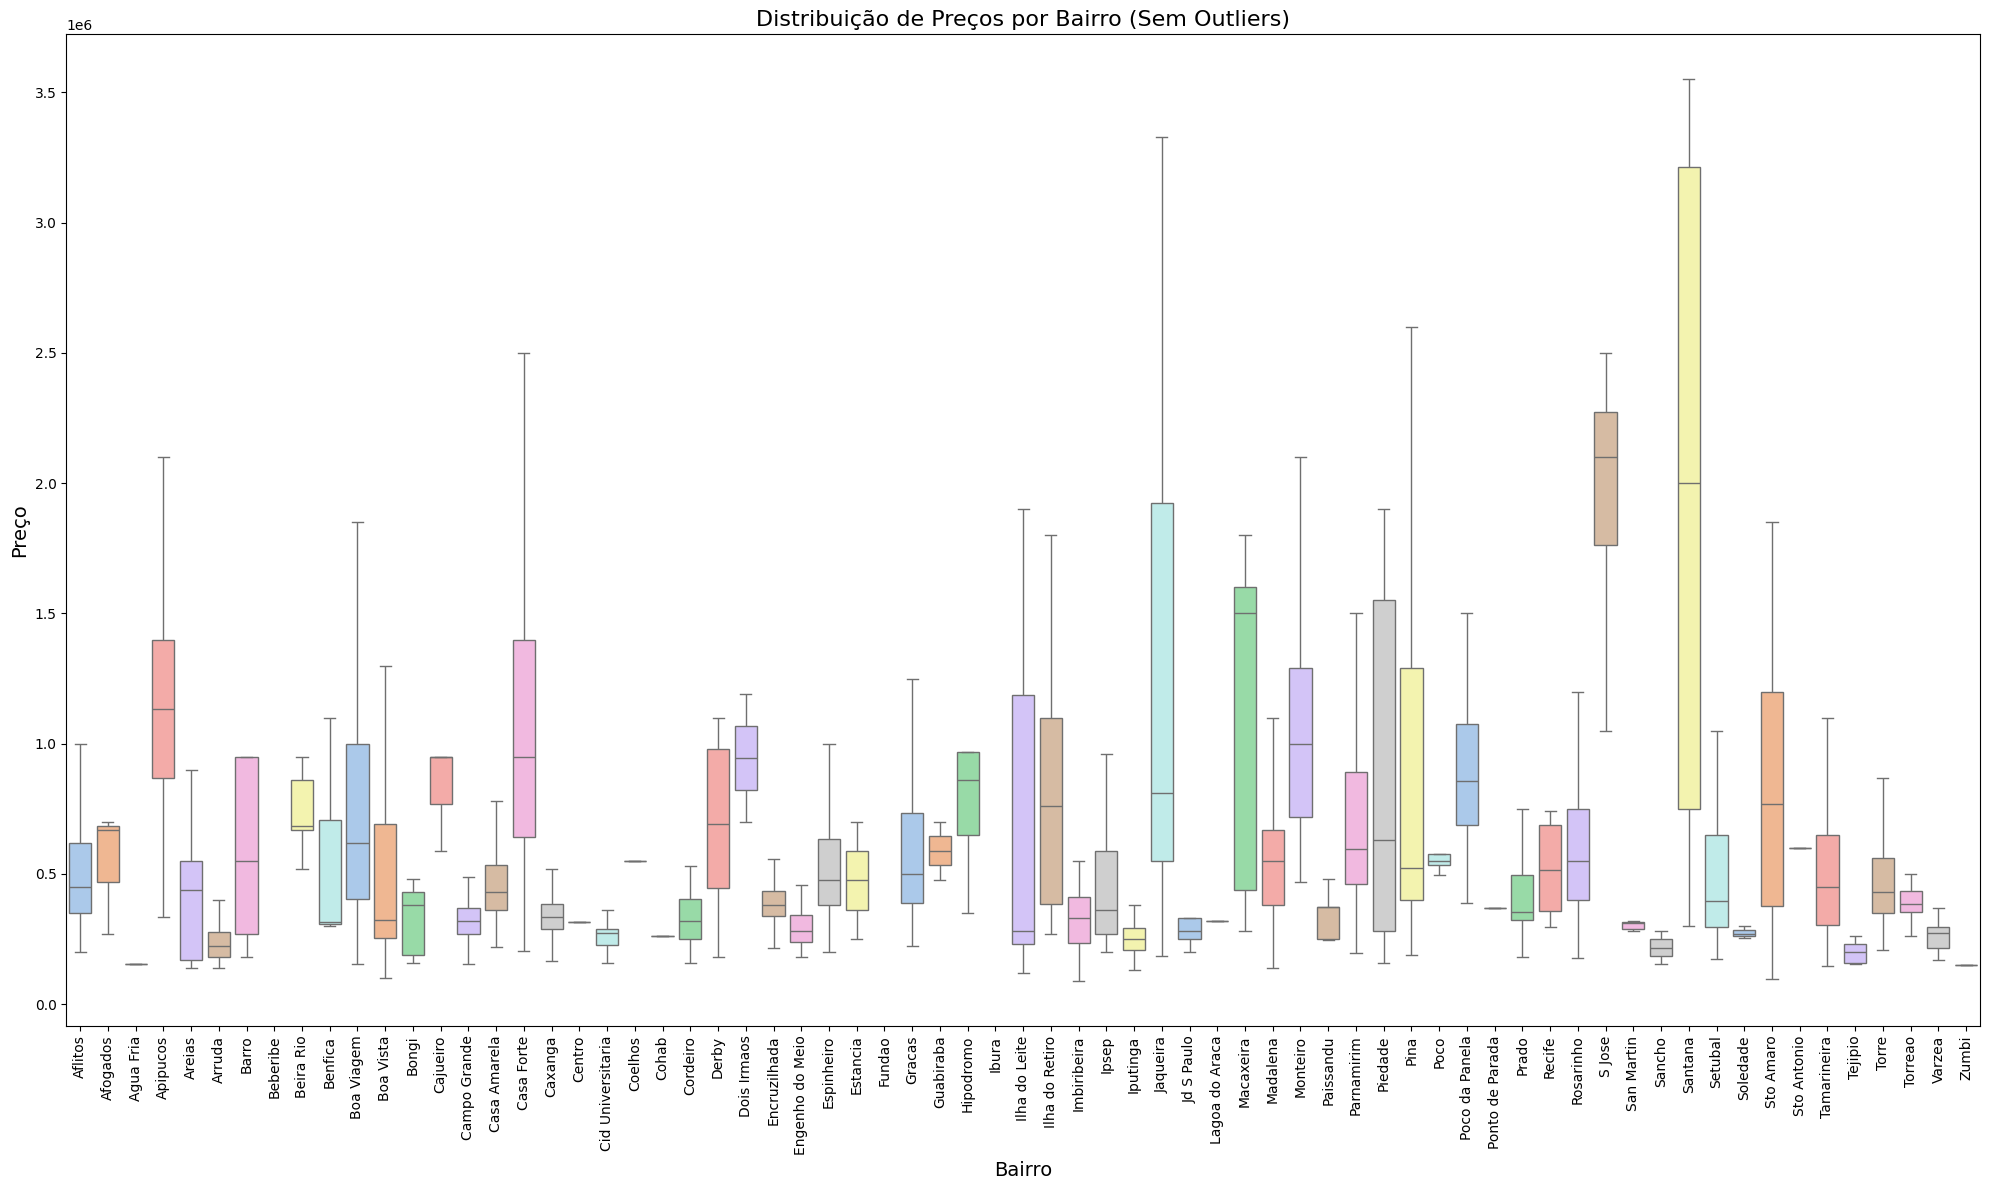

In [38]:

# Listar os bairros
bairros = ['bairro_Aflitos', 'bairro_Afogados', 'bairro_Agua Fria', 'bairro_Apipucos', 'bairro_Areias', 
           'bairro_Arruda', 'bairro_Barro', 'bairro_Beberibe', 'bairro_Beira Rio', 'bairro_Benfica', 
           'bairro_Boa Viagem', 'bairro_Boa Vista', 'bairro_Bongi', 'bairro_Cajueiro', 'bairro_Campo Grande', 
           'bairro_Casa Amarela', 'bairro_Casa Forte', 'bairro_Caxanga', 'bairro_Centro', 'bairro_Cid Universitaria', 
           'bairro_Coelhos', 'bairro_Cohab', 'bairro_Cordeiro', 'bairro_Derby', 'bairro_Dois Irmaos', 
           'bairro_Encruzilhada', 'bairro_Engenho do Meio', 'bairro_Espinheiro', 'bairro_Estancia', 'bairro_Fundao', 
           'bairro_Gracas', 'bairro_Guabiraba', 'bairro_Hipodromo', 'bairro_Ibura', 'bairro_Ilha do Leite', 
           'bairro_Ilha do Retiro', 'bairro_Imbiribeira', 'bairro_Ipsep', 'bairro_Iputinga', 'bairro_Jaqueira', 
           'bairro_Jd S Paulo', 'bairro_Lagoa do Araca', 'bairro_Macaxeira', 'bairro_Madalena', 'bairro_Monteiro', 
           'bairro_Paissandu', 'bairro_Parnamirim', 'bairro_Piedade', 'bairro_Pina', 'bairro_Poco', 
           'bairro_Poco da Panela', 'bairro_Ponto de Parada', 'bairro_Prado', 'bairro_Recife', 'bairro_Rosarinho', 
           'bairro_S Jose', 'bairro_San Martin', 'bairro_Sancho', 'bairro_Santana', 'bairro_Setubal', 'bairro_Soledade', 
           'bairro_Sto Amaro', 'bairro_Sto Antonio', 'bairro_Tamarineira', 'bairro_Tejipio', 'bairro_Torre', 
           'bairro_Torreao', 'bairro_Varzea', 'bairro_Zumbi']

# Transformar as colunas binárias de bairros em uma única coluna
df_melted_bairros = df.melt(id_vars=['preco'], value_vars=bairros, var_name='bairro', value_name='presente')

# Filtrar apenas os bairros presentes (onde a coluna 'presente' é 1)
df_melted_bairros = df_melted_bairros[df_melted_bairros['presente'] == 1]

# Remover o prefixo "bairro_" dos nomes dos bairros
df_melted_bairros['bairro'] = df_melted_bairros['bairro'].str.replace('bairro_', '', regex=False)

# Configurar tamanho da figura (aumentando tanto na vertical quanto na horizontal)
plt.figure(figsize=(20, 12))

# Boxplot para os bairros
sns.boxplot(x='bairro', y='preco', data=df_melted_bairros, palette='pastel', showfliers=False)

# Títulos e rótulos
plt.title('Distribuição de Preços por Bairro (Sem Outliers)', fontsize=16)
plt.xlabel('Bairro', fontsize=14)
plt.ylabel('Preço', fontsize=14)

# Ajustar o layout para o gráfico
plt.xticks(rotation=90)  # Rotacionar os rótulos dos bairros para facilitar a leitura
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_13172\3779498824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_price.values, y=correlation_with_price.index, palette='coolwarm')


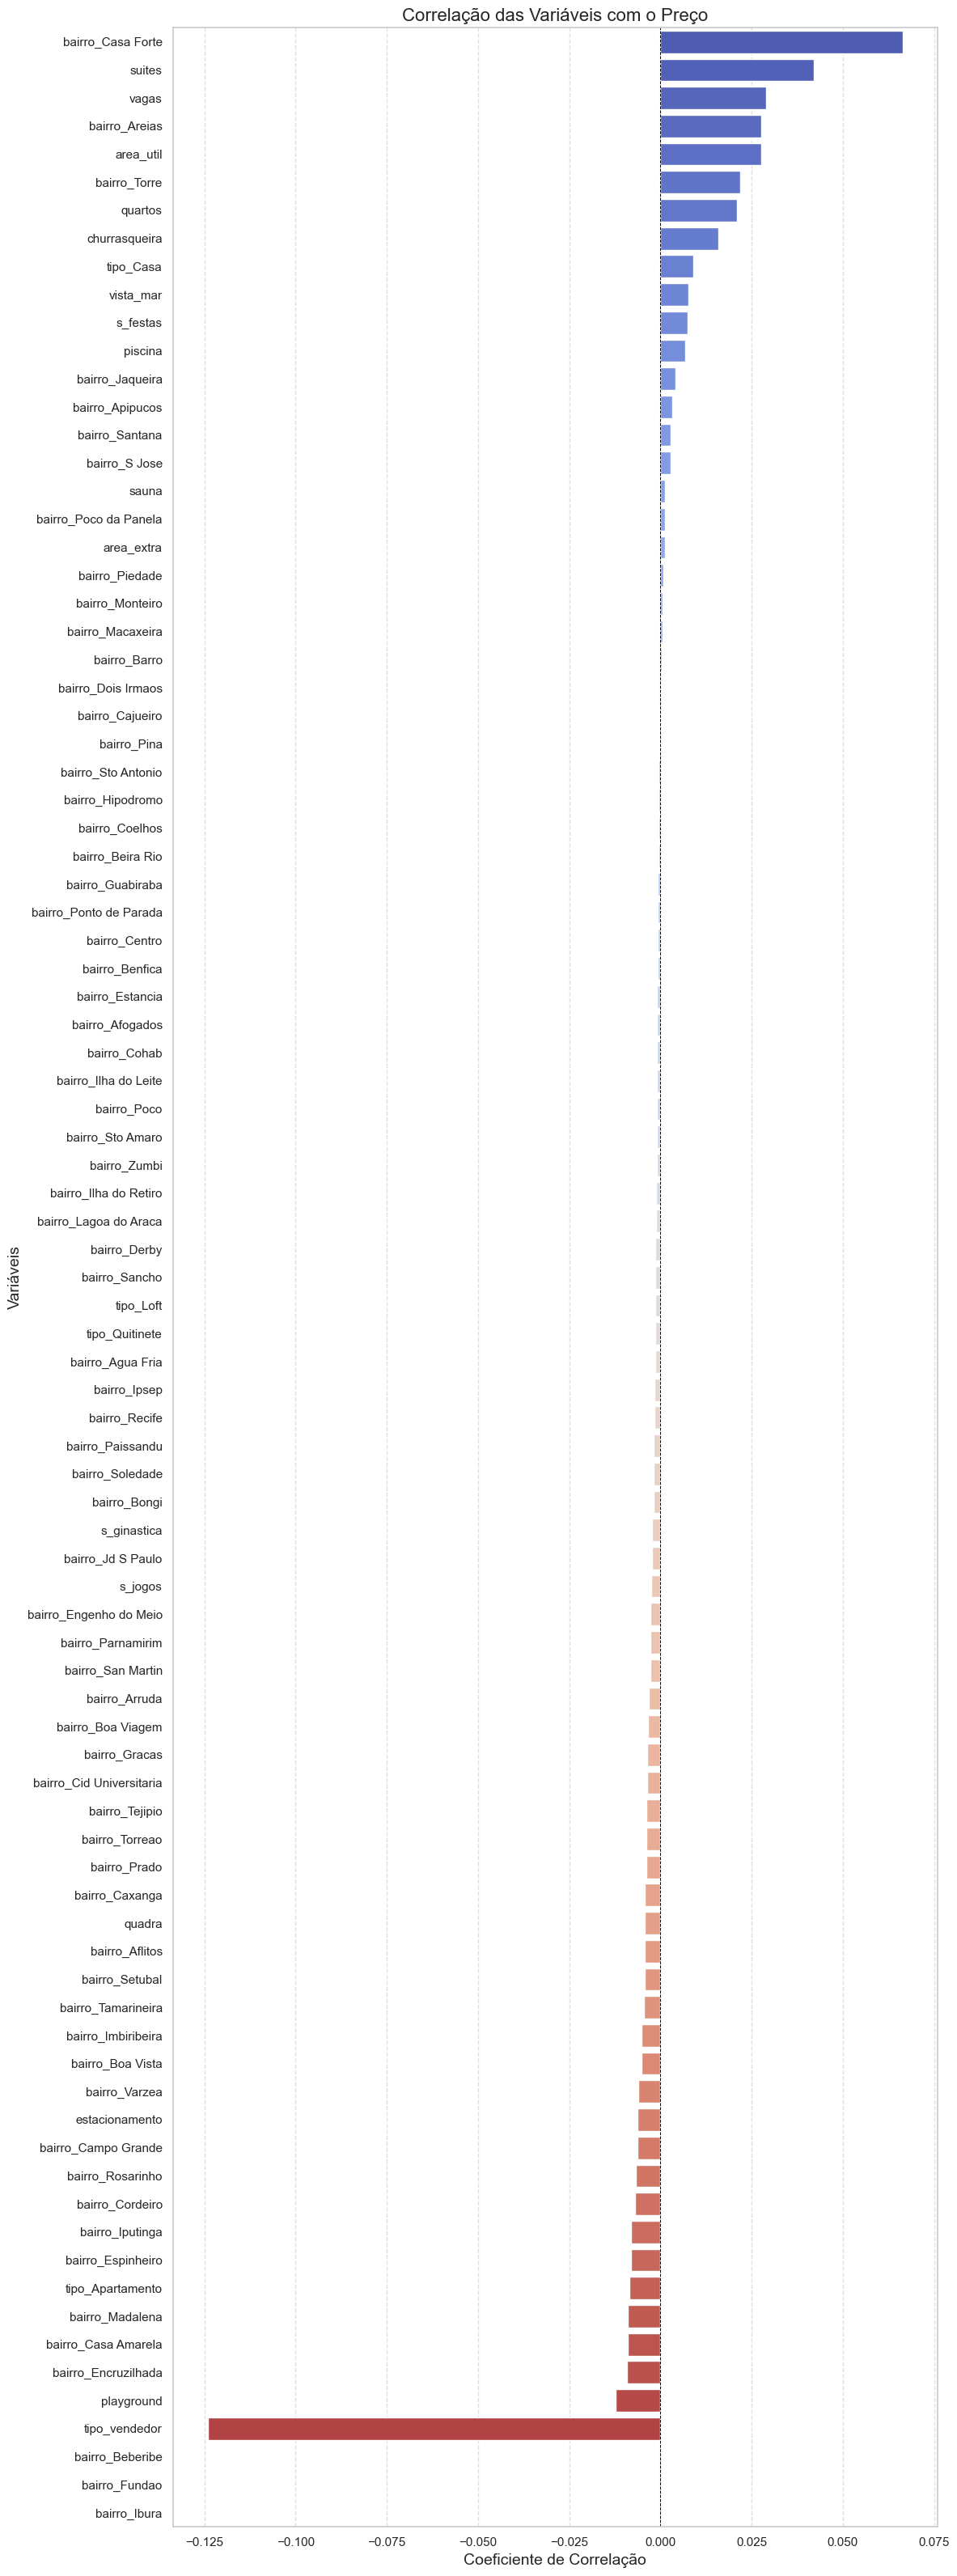

In [69]:
# Calcula a matriz de correlação e seleciona apenas as correlações com a coluna 'preco'
correlation_with_price = df.corr()['preco'].sort_values(ascending=False)

# Remove a correlação de 'preco' com ele mesmo (que é sempre 1) e exclui a coluna 'Id' se existir
columns_to_exclude = ['preco', 'Id']
correlation_with_price = correlation_with_price[~correlation_with_price.index.isin(columns_to_exclude)]

# Configura o gráfico de barras
plt.figure(figsize=(12, 32))
sns.barplot(x=correlation_with_price.values, y=correlation_with_price.index, palette='coolwarm')

# Adiciona rótulos e título
plt.title('Correlação das Variáveis com o Preço', fontsize=16)
plt.xlabel('Coeficiente de Correlação', fontsize=14)
plt.ylabel('Variáveis', fontsize=14)
plt.axvline(0, color='black', linestyle='--', linewidth=0.7)  # Linha indicando correlação nula

# Adiciona a grade
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Treinamento do Modelo

In [70]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np

# Separar os dados onde 'preco' não é NA e os que são
df_preco = df[df['preco'].notna()]
df_answer = df[df['preco'].isna()]

# Divisão em train e test (80% para train, 20% para test)
train, test = train_test_split(df_preco, test_size=0.1, random_state=42)

# Identificar colunas numéricas para calcular a correlação
numerical_columns = train.select_dtypes(include=[np.number]).columns

# Calcular a correlação com a variável 'preco'
correlation_matrix = train[numerical_columns].corr()
correlation_with_target = correlation_matrix['preco'].drop('preco').sort_values(ascending=False)

# Selecionar features com correlação relevante (positiva ou negativa)
threshold = 0.005
selected_features = correlation_with_target[
    (correlation_with_target >= threshold) | (correlation_with_target <= -threshold)
].index.tolist()

# Remover a coluna Id das features selecionadas (se existir)
if 'Id' in selected_features:
    selected_features.remove('Id')

print("Features selecionadas:", selected_features)

# Preparar os datasets para o modelo
X_train = train[selected_features]
y_train = train['preco']

X_test = test[selected_features]
y_test = test['preco']

# Configurando modelos e hiperparâmetros para GridSearchCV
models_and_params = {
    'RandomForest': (RandomForestRegressor(random_state=42), {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }),
    'GradientBoosting': (GradientBoostingRegressor(random_state=42), {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }),
    'HistGradientBoosting': (HistGradientBoostingRegressor(random_state=42), {
        'max_iter': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [10, 20, 30],
        'l2_regularization': [0.0, 0.1, 1.0],
    }),
    'LinearRegression': (LinearRegression(), {}),
    'Ridge': (Ridge(), {
        'alpha': [0.1, 1.0, 10.0, 100.0],
        'solver': ['auto', 'saga', 'cholesky']
    }),
    'Lasso': (Lasso(), {
        'alpha': [0.01, 0.1, 1.0, 10.0],
        'max_iter': [1000, 5000, 10000]
    }),
    'SVR': (SVR(), {
        'kernel': ['linear', 'rbf', 'poly'],
        'C': [0.1, 1.0, 10.0, 100.0],
        'epsilon': [0.01, 0.1, 1.0]
    })
}

# Melhor modelo e hiperparâmetros
best_model = None
best_score = -np.inf  # Para R², maior é melhor
best_name = ""
best_params = {}

# Realizando GridSearchCV para cada modelo
for name, (model, params) in models_and_params.items():
    print(f"\nTreinando {name} com GridSearchCV...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring='r2',
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"Melhor R² para {name}: {grid_search.best_score_}")
    print(f"Melhores parâmetros para {name}: {grid_search.best_params_}")
    
    if grid_search.best_score_ > best_score:
        best_model = grid_search.best_estimator_
        best_score = grid_search.best_score_
        best_name = name
        best_params = grid_search.best_params_

# Avaliar o melhor modelo no conjunto de teste
y_test_pred = best_model.predict(X_test)
test_r2 = best_model.score(X_test, y_test)

print(f"\nMelhor modelo: {best_name}")
print(f"Melhores parâmetros: {best_params}")
print(f"Desempenho no teste - R²: {test_r2}")

Features selecionadas: ['bairro_Casa Forte', 'suites', 'vagas', 'bairro_Areias', 'area_util', 'bairro_Torre', 'quartos', 'churrasqueira', 's_festas', 'tipo_Casa', 'vista_mar', 'piscina', 'bairro_Imbiribeira', 'bairro_Boa Viagem', 'bairro_Campo Grande', 'estacionamento', 'bairro_Varzea', 'bairro_Rosarinho', 'bairro_Cordeiro', 'bairro_Iputinga', 'bairro_Espinheiro', 'tipo_Apartamento', 'bairro_Madalena', 'bairro_Encruzilhada', 'bairro_Casa Amarela', 'playground', 'tipo_vendedor']

Treinando RandomForest com GridSearchCV...
Fitting 3 folds for each of 144 candidates, totalling 432 fits
Melhor R² para RandomForest: -6.412204128945902
Melhores parâmetros para RandomForest: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}

Treinando GradientBoosting com GridSearchCV...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Melhor R² para GradientBoosting: -40.512918281866376
Melhores parâmetros para GradientBoosting: {'learning_rate': 0.01, 'max_d

c:\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Melhor R² para Ridge: 0.039444154122080355
Melhores parâmetros para Ridge: {'alpha': 0.1, 'solver': 'saga'}

Treinando Lasso com GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Melhor R² para Lasso: -5.63818615014863
Melhores parâmetros para Lasso: {'alpha': 10.0, 'max_iter': 1000}

Treinando SVR com GridSearchCV...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Melhor R² para SVR: 0.1647965855937316
Melhores parâmetros para SVR: {'C': 100.0, 'epsilon': 0.01, 'kernel': 'linear'}

Melhor modelo: SVR
Melhores parâmetros: {'C': 100.0, 'epsilon': 0.01, 'kernel': 'linear'}
Desempenho no teste - R²: 0.09068197798517907


## 6. Validação do Modelo

In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Função para calcular o RMSPE
def rmspe(y_true, y_pred):
    percentage_error = ((y_true - y_pred) / y_true) ** 2
    return np.sqrt(np.mean(percentage_error))

# Avaliar o modelo no conjunto de teste
y_pred = best_model.predict(X_test)

# Calcular métricas de desempenho
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
test_rmspe = rmspe(y_test, y_pred)

print("\nMétricas de avaliação no conjunto de teste:")
print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSPE: {test_rmspe:.4f}")


Métricas de avaliação no conjunto de teste:
R²: 0.0907
MSE: 367043610851.5456
MAE: 229242.5848
RMSPE: 0.8458


## 7. Aplicação do Modelo na Competição

In [73]:
from datetime import datetime

# Aplicar o modelo no conjunto 'answer'
X_answer = df_answer[selected_features]
df_answer_result = df_answer[['Id']].copy()
df_answer_result['preco'] = best_model.predict(X_answer)

# Gerar timestamp para o nome do arquivo
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"data/resposta_final_{timestamp}.csv"

# Salvar a resposta final
df_answer_result.to_csv(file_name, index=False)

print(f"\nArquivo '{file_name}' salvo com as predições para o conjunto answer.")


Arquivo 'data/resposta_final_20241212_221500.csv' salvo com as predições para o conjunto answer.
